<a href="https://colab.research.google.com/github/reshmajayaghosh/ICT/blob/main/Deep_Learning_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning with Keras — California Housing Regression**

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **`Stage 1.1 — Data Loading & Exploratory Data Analysis (EDA)`**

*`1. Load and Inspect Dataset`*

In [78]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (20640, 8)
Target Shape: (20640,)


In [79]:
df = pd.DataFrame(X, columns=housing.feature_names)
df["Target"] = y

df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


*`2. Descriptive Statistics`*

In [80]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


*`3. Visualisations`*

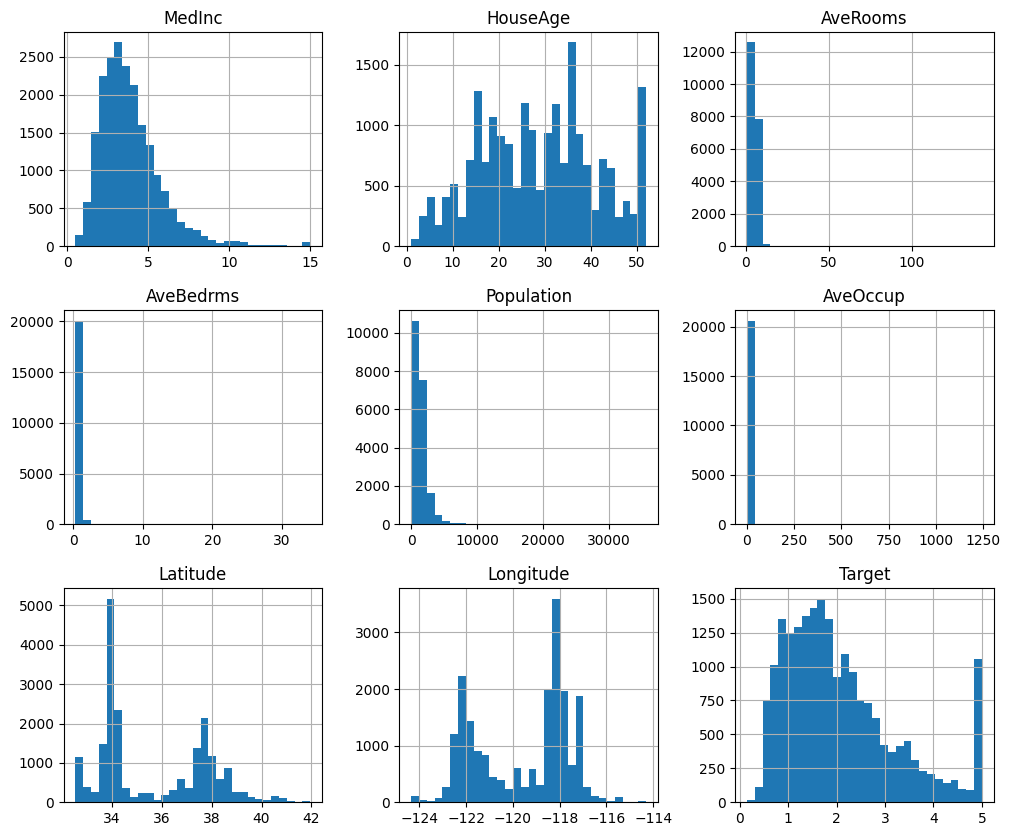

In [81]:
df.hist(figsize=(12,10), bins=30)
plt.show()

`MedInc appears right-skewed`

**Correlation Heatmap**

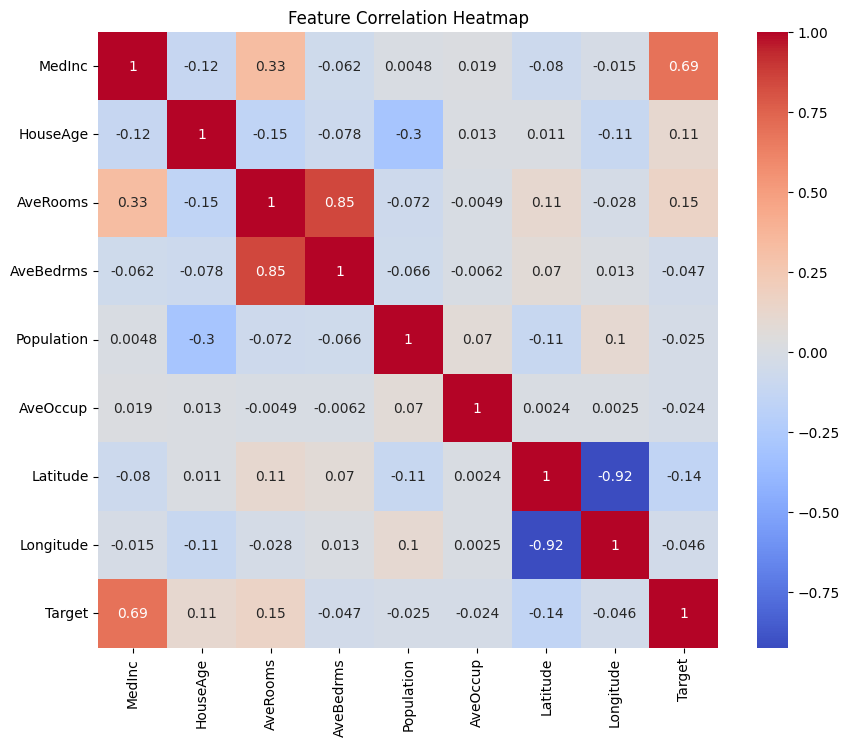

In [82]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


*  MedInc → strong positive
*  AveRooms → moderate positive



**Scatter Plots**

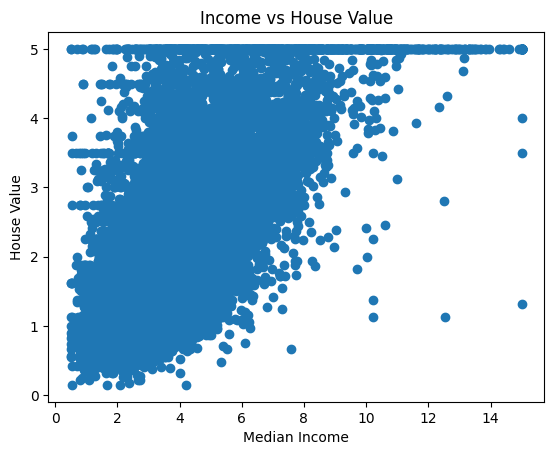

In [83]:
plt.scatter(df["MedInc"], df["Target"])
plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Income vs House Value")
plt.show()

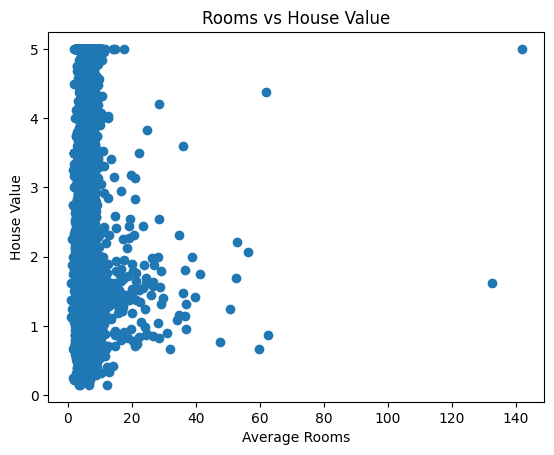

In [84]:
plt.scatter(df["AveRooms"], df["Target"])
plt.xlabel("Average Rooms")
plt.ylabel("House Value")
plt.title("Rooms vs House Value")
plt.show()

# **`Stage 1.2 — Data Preprocessing`**

*`4. Train / Validation / Test Split`*

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

In [86]:
print("Train:", X_train.shape)

Train: (14448, 8)


In [87]:
print("Validation:", X_val.shape)

Validation: (3096, 8)


In [88]:
print("Test:", X_test.shape)

Test: (3096, 8)


*`5. Feature Scaling`*

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


X_val_scaled = scaler.transform(X_val)


# **`Stage 1.3 — Model Architecture Design`**

*`6. Build Deep Neural Network`*

In [90]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [91]:
model = keras.Sequential([

    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.BatchNormalization(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(32, activation="relu"),

    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [92]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,105 (27.75 KB)

 Trainable params: 6,977 (27.25 KB)

 Non-trainable params: 128 (512.00 B)

*`7. Loss Function Choice`*

In [93]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [94]:
loss_function = "mse"

*`8. Evaluation Metrics`*

In [95]:
metrics = ["mae"]

# **`Stage 1.4 — Model Training`**

*`9. Compile Model`*

In [96]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

*`10. Callbacks`*

In [97]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_regression_model.keras",
    monitor="val_loss",
    save_best_only=True
)

**Train Model**

In [98]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.7450 - mae: 0.6260 - val_loss: 0.5779 - val_mae: 0.5172
Epoch 2/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5205 - mae: 0.5202 - val_loss: 0.4762 - val_mae: 0.4688
Epoch 3/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4573 - mae: 0.4847 - val_loss: 0.5260 - val_mae: 0.5040
Epoch 4/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4349 - mae: 0.4710 - val_loss: 0.4296 - val_mae: 0.4474
Epoch 5/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4231 - mae: 0.4634 - val_loss: 0.4815 - val_mae: 0.4730
Epoch 6/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4010 - mae: 0.4485 - val_loss: 0.3951 - val_mae: 0.4295
Epoch 7/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3904 - mae: 0.4422 - val_loss: 0.3861 - val_mae: 0.4241
Epoch 8/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3766 - mae: 0.4324 - val_loss: 0.3967 - val_mae: 0.4307
Epoch 9/50
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - lo

# **`Stage 1.5 — Training Curve Analysis`**

*`11. Training vs Validation Loss`*

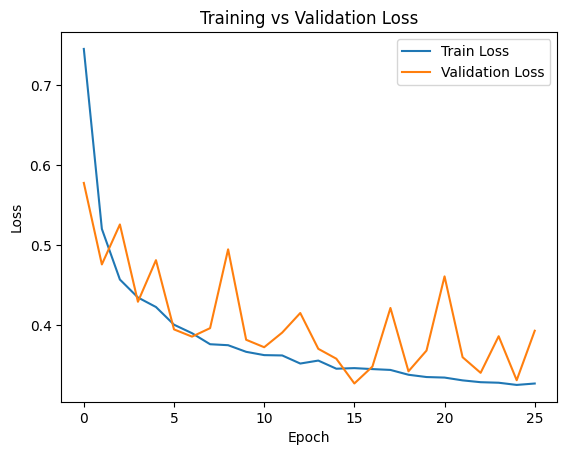

In [99]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

*`12. Metric Curve (MAE)`*

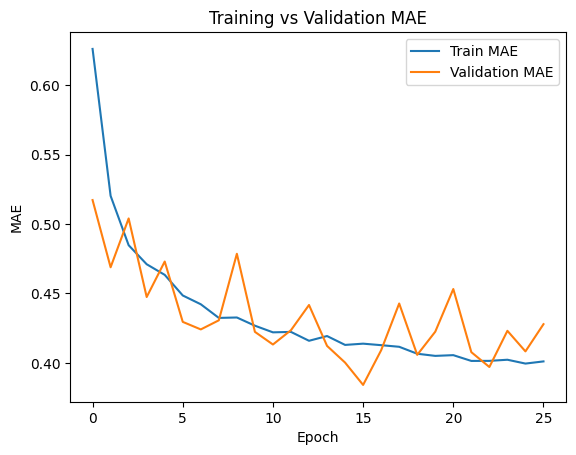

In [100]:
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")

plt.legend()
plt.show()

# **`Stage 1.6 — Model Evaluation`**

`13. Test Set Evaluation`

In [101]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3044 - mae: 0.3750
Test Loss: 0.30437779426574707
Test MAE: 0.3749770522117615


*`14. Prediction Analysis`*

In [102]:
y_pred = model.predict(X_test_scaled)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [103]:
y_pred

array([[0.7330452],
       [1.1030507],
       [2.929988 ],
       ...,
       [1.1719859],
       [1.4827203],
       [2.3660078]], dtype=float32)

**Actual vs Predicted Scatter Plot**

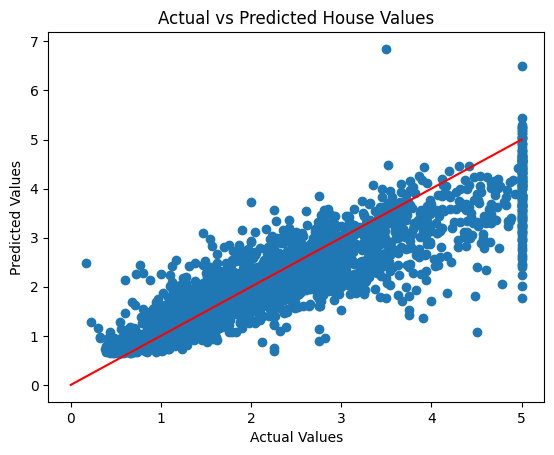

In [104]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.plot([0,5],[0,5], color="red")

plt.show()

**Residual Histogram**

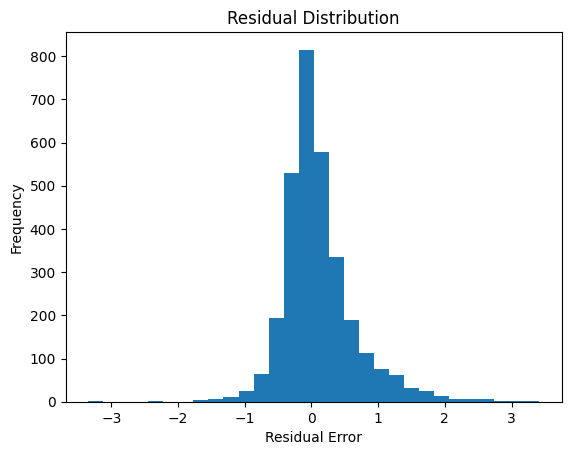

In [105]:
residuals = y_test - y_pred.flatten()

plt.hist(residuals, bins=30)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

**Largest Errors**

In [106]:
errors = np.abs(residuals)

largest_errors = np.argsort(errors)[-10:]

print("Samples with largest prediction errors:")
print(largest_errors)

Samples with largest prediction errors:
[ 995 1212 2362  487 1199  992 1429 2800 1803  321]
